# ティックから実現ボラティリティ: シグネチャプロット、ジャンプ、オーバーナイトリスク

実現分散、つまり日中リターンの二乗和は、標準的なノンパラメトリックのボラティリティ推定量
です。これをうまく計算するのは、ほとんど*サンプリング*の問題です。速く取りすぎればビッド・
アスクの跳ね返りが推定値を膨らませ、遅く取りすぎれば情報を捨てることになります。

ティックが時刻順で保存されていれば、同じデータを別の頻度で取り直すのは `time_bucket` の
クエリ1つです。だから定番の診断はそれぞれ数行で済みます。

このレシピで進めるのは次の4つです。

1. 5分足から日次の実現分散を計算する
2. 10通りのサンプリング間隔でボラティリティのシグネチャプロットを描く
3. 二乗和と bipower variation でジャンプを連続的な分散から切り分ける
4. 実際の SPY の分散を、オーバーナイトと日中に分解する

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import col, count_star, time_bucket
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("alpha_rv"), create=True)

## 1. データ

1銘柄ぶんの密な合成約定を5セッション、1日あたり10万件。1行が1約定です。

| 列 | 型 | 意味 |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | 約定時刻、昇順 |
| `symbol` | `string` | 銘柄コード。ここでは `SPX` |
| `price` | `float64` | 約定価格 |
| `size` | `int64` | 約定株数 |
| `exchange` | `string` | 報告した取引所 |
| `side` | `string` | `B` は買い主導、`S` は売り主導 |

生成器は約定をミッドの両側に置くので、本物のビッド・アスクの跳ね返りが入ります。それこそが
シグネチャプロットで浮かび上がるマイクロストラクチャのノイズです。

In [2]:
trades = cu.make_trades(symbols=["SPX"], days=5, trades_per_day=100_000, seed=42)
print(f"{trades.num_rows:,} rows x {trades.num_columns} columns")
trades.to_pandas().head()

544,568 rows x 6 columns


,ts,symbol,price,size,exchange,side
0,2026-06-01 13:30:00.008398+00:00,SPX,318.59,1,IEX,S
1,2026-06-01 13:30:00.052268+00:00,SPX,318.66,1,IEX,B
2,2026-06-01 13:30:00.062399+00:00,SPX,318.67,100,ARCA,B
3,2026-06-01 13:30:00.143543+00:00,SPX,318.60,1,IEX,S
4,2026-06-01 13:30:00.144706+00:00,SPX,318.60,200,NASDAQ,S


さらに4日目の場中に、**+1.5% の1回きりのジャンプ**を、以降の価格すべての水準シフトとして
注入します。ジャンプ検出の節に、見つけるべき本物が要るからです。テーブルに入れるのは
`ts`、`symbol`、`price`、`size` だけです。

In [3]:
jump_ts = pd.Timestamp("2026-06-04 17:00:00", tz="UTC")
tdf = trades.to_pandas()
tdf.loc[tdf["ts"] >= jump_ts, "price"] *= 1.015  # permanent level shift

schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("price", pa.float64()),
        pa.field("size", pa.int64()),
    ]
)
db.create_table("trades", schema, time_column="ts", sort_key=["ts"])
db.append(
    "trades",
    pa.Table.from_pandas(tdf[["ts", "symbol", "price", "size"]], preserve_index=False).cast(schema),
    note="5 sessions, +1.5% jump injected 06-04 17:00",
)
print(f"{len(tdf):,} trades over {tdf.ts.dt.date.nunique()} sessions")

544,568 trades over 5 sessions


## 2. 5分足からの日次実現分散

慣習は、5分にバケットして各バケットの最後の約定価格を取り、セッション内の対数リターンを
二乗して足す、というものです。

`time_bucket('5m', ts)` と `last_value(price ORDER BY ts)` がバケット化をストリーミングの
1パスで済ませ、日ごとの差分と合計は pandas で2行です。年率ボラティリティは
`sqrt(RV_day * 252)` になります。

In [4]:
def price_bars(width: str):
    """Last trade price per bucket - the same frame at any sampling width."""
    return (
        db.table("trades")
        .group_by(time_bucket(width, col("ts")).alias("bar"))
        .agg(close=col("price").last("ts"), n_trades=count_star())
        .sort("bar")
    )


bars5 = price_bars("5m").to_pandas()
bars5["day"] = bars5["bar"].dt.date
bars5["r"] = np.log(bars5["close"]).groupby(bars5["day"]).diff()  # within-session only

rv_daily = bars5.groupby("day")["r"].apply(lambda r: (r**2).sum()).rename("rv")
pd.DataFrame({"rv": rv_daily, "ann_vol_%": np.sqrt(rv_daily * 252) * 100}).round(5)

,rv,ann_vol_%
day,,
2026-06-01,0.00016,20.06011
2026-06-02,0.00019,21.85544
2026-06-03,0.00019,21.68643
2026-06-04,0.00050,35.41038
2026-06-05,0.00019,21.69348


## 3. シグネチャプロット

実現分散を1秒から30分までのサンプリング間隔で計算し直します。どれも*同じ*フレームで、
バケット幅が違うだけです。

摩擦のない世界なら実現分散は頻度によらず平らになります。ビッド・アスクの跳ね返りがあると、
観測されるリターンは `真のリターン + iid ノイズ` になり、ノイズの分散は*1観測あたり*
払われます。だから間隔が縮むほど実現分散は跳ね上がります。

カーブが平らになる肘の位置が、信用できる最高の頻度です。流動性の高い銘柄では数分あたりに
座るので、業界の既定値が「5分の実現分散」なのです。

In [5]:
INTERVALS_S = [1, 5, 15, 30, 60, 120, 300, 600, 900, 1800]

sig_rows = []
for sec in INTERVALS_S:
    b = price_bars(f"{sec}s").to_pandas()
    b["day"] = b["bar"].dt.date
    r = np.log(b["close"]).groupby(b["day"]).diff()
    rv = (r**2).groupby(b["day"]).sum()
    sig_rows.append({"interval_s": sec, "ann_vol": float(np.sqrt(rv.mean() * 252))})
sig = pd.DataFrame(sig_rows)

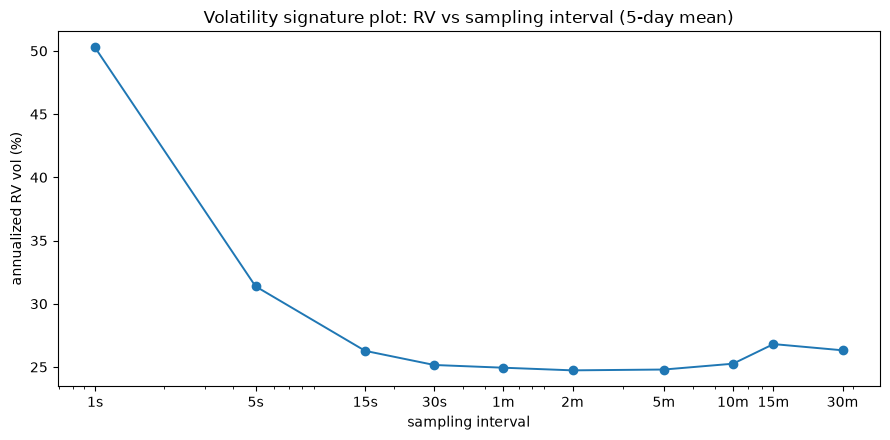

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sig["interval_s"], sig["ann_vol"] * 100, "o-", lw=1.4)
ax.set_xscale("log")
ax.set_xticks(INTERVALS_S)
ax.set_xticklabels(["1s", "5s", "15s", "30s", "1m", "2m", "5m", "10m", "15m", "30m"])
ax.set_title("Volatility signature plot: RV vs sampling interval (5-day mean)")
ax.set_xlabel("sampling interval")
ax.set_ylabel("annualized RV vol (%)")
fig.tight_layout()

教科書どおりの形です。1秒の推定値は安定値のおよそ2倍になります。その頻度では、観測される
「リターン」の大部分がスプレッドだからです。

ここではカーブが1分ほどで平らになります。実際のティックデータではノイズ源がもっと多いので、
肘はたいていもう少し外側に座ります。だから5分という慣習があります。

## 4. ジャンプ: bipower variation と実現分散

実現分散が収束するのは*全体の*二次変分、つまり連続的な分散**プラス**ジャンプの二乗です。

Barndorff-Nielsen と Shephard の bipower variation
$BV = \frac{\pi}{2}\sum |r_i||r_{i-1}|$ はジャンプに頑健です。1つの巨大なリターンが二乗され
るのではなく、有限の隣人と掛け合わされるからです。したがって `max(RV - BV, 0)` がジャンプの
寄与を切り出します。

1.5% のジャンプを入れた4日目が光るはずです。ほかの日は実現分散と BV が近いはずです。

In [7]:
def bipower(r: pd.Series) -> float:
    a = r.abs().to_numpy()
    return float(np.pi / 2 * np.nansum(a[1:] * a[:-1]))


bv_daily = bars5.groupby("day")["r"].apply(bipower).rename("bv")
jumps = pd.DataFrame({"rv": rv_daily, "bv": bv_daily})
jumps["jump_var"] = (jumps["rv"] - jumps["bv"]).clip(lower=0)
jumps["jump_share_%"] = 100 * jumps["jump_var"] / jumps["rv"]
jumps.round(5)

,rv,bv,jump_var,jump_share_%
day,,,,
2026-06-01,0.00016,0.00018,0.00000,0.00000
2026-06-02,0.00019,0.00018,0.00001,6.92283
2026-06-03,0.00019,0.00019,0.00000,0.00000
2026-06-04,0.00050,0.00024,0.00025,50.98579
2026-06-05,0.00019,0.00020,0.00000,0.00000


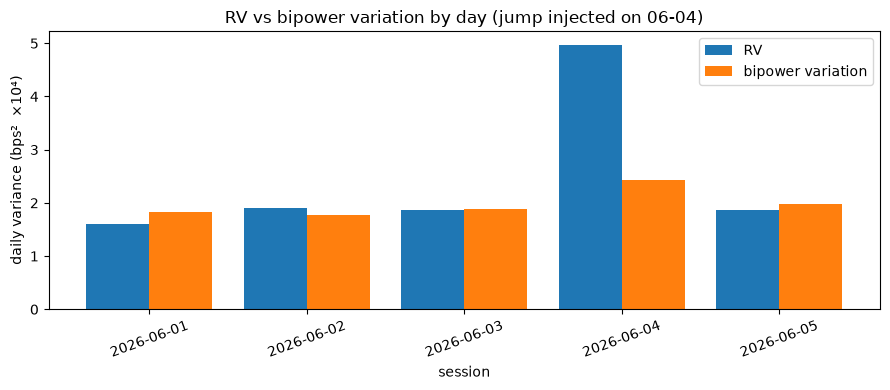

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(jumps))
ax.bar(x - 0.2, jumps["rv"] * 1e4, width=0.4, label="RV")
ax.bar(x + 0.2, jumps["bv"] * 1e4, width=0.4, label="bipower variation")
ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in jumps.index], rotation=20)
ax.set_title("RV vs bipower variation by day (jump injected on 06-04)")
ax.set_xlabel("session")
ax.set_ylabel("daily variance (bps²  ×10⁴)")
ax.legend()
fig.tight_layout()

ジャンプを入れた日は実現分散が BV をはっきり上回り、その差は注入した
`ln(1.015)² ≈ 2.2e-4` に近い値です。ふつうの日はノイズの範囲で一致します。

## 5. 実際の SPY データで、オーバーナイトと日中を分ける

終値から終値までの分散は、オーバーナイトのギャップ `open/prev close` と日中の部分
`close/open` に分かれます。

キャッシュしてある SPY の30分足を使い、SQL 1つでセッションの始値と終値を取ります。
`time_bucket('1d', ts, 'America/New_York')` が取引所の日でバケットします。UTC の日では
ありません。`cu.fetch_intraday` が返すのは `ts`、`symbol`、`open`、`high`、`low`、`close`、
`volume` で、このうち4つを使います。

In [9]:
spy = cu.fetch_intraday(["SPY"], period="30d", interval="30m")
print(f"{spy.num_rows:,} rows x {spy.num_columns} columns")
spy.to_pandas().head()

390 rows x 7 columns


,ts,symbol,open,high,low,close,volume
0,2026-06-09 13:30:00+00:00,SPY,743.630005,746.900024,743.280029,744.380005,5794700
1,2026-06-09 14:00:00+00:00,SPY,744.363770,745.044983,739.419983,741.210022,5431656
2,2026-06-09 14:30:00+00:00,SPY,741.169983,741.710022,734.650024,737.750000,6250448
3,2026-06-09 15:00:00+00:00,SPY,737.789978,738.419983,730.770020,731.000000,3768889
4,2026-06-09 15:30:00+00:00,SPY,731.000000,732.750000,728.960022,729.059998,6137253


In [10]:
sschema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("open", pa.float64()),
        pa.field("close", pa.float64()),
    ]
)
db.create_table("spy_30m", sschema, time_column="ts", sort_key=["ts"])
db.append("spy_30m", spy.select(["ts", "symbol", "open", "close"]).cast(sschema))

days = (
    db.table("spy_30m")
    .group_by(time_bucket("1d", col("ts"), timezone="America/New_York").alias("day"))
    .agg(day_open=col("open").first("ts"), day_close=col("close").last("ts"))
    .sort("day")
    .to_pandas()
)

r_on = np.log(days["day_open"] / days["day_close"].shift(1)).dropna()
r_id = np.log(days["day_close"] / days["day_open"]).iloc[1:]
var_on, var_id = r_on.var(), r_id.var()
print(
    f"{len(days)} sessions of SPY\n"
    f"overnight var share: {var_on / (var_on + var_id):.0%}   "
    f"intraday var share: {var_id / (var_on + var_id):.0%}\n"
    f"ann vol - overnight: {np.sqrt(var_on * 252):.1%}, intraday: {np.sqrt(var_id * 252):.1%}"
)

30 sessions of SPY
overnight var share: 55%   intraday var share: 45%
ann vol - overnight: 9.7%, intraday: 8.7%


SPY の全分散のうち、意味のある割合が市場の閉まっているあいだに積み上がります。日中の実現
分散が決して見ないリスクで、終値から終値で評価するもの、つまり VaR やオプションには効いて
きます。

セッションが30ほどしかないので、この分割は推定というより例示です。本番では何年ぶんもの
バーで走らせることになりますが、それは同じクエリを大きなテーブルにかけるだけです。

## まとめ

- ティックのテーブル1つと、10通りの幅の `time_bucket` があれば、シグネチャプロットが完成
  します。取り直しに要るのはクエリだけで、パイプラインは要りません。なお1分未満の幅は単位を
  綴ります。`'30s'` ではなく `'30sec'` です。
- マイクロストラクチャのノイズは合成データでも見えます。ビッド・アスクの跳ね返りが1秒の
  実現分散を安定値のおよそ2倍にしました。5分サンプリングが慣習的に安全な肘です。
- 実現分散から bipower variation を引くと、注入した1日のジャンプをきれいに拾い、その大きさ
  まで復元しました。連続ボラティリティの予測で欲しい、ジャンプに頑健な分母が BV です。
- オーバーナイトの分散は本物のリスクで、SPY の全体のうち目に見える割合を占めます。日中の
  実現分散はそれを構造的に除外します。終値から終値のボラティリティと比べる前に、分解して
  ください。

In [11]:
db.close()